# Analyse Complète : Sélection Globale et Évaluation Entraînement/Test
Ce notebook combine deux étapes cruciales :
1. **Sélection Globale** : Identifier les gènes les plus impactants sur l'ensemble des 62 patients.
2. **Évaluation Rigoureuse** : Mesurer la performance réelle de ces gènes en séparant les données en Entraînement et Test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')

# Chargement
df = pd.read_csv('./colon cancer dataset.csv')
X_raw = df.drop('Class', axis=1)
y_raw = LabelEncoder().fit_transform(df['Class'])
X_scaled_full = StandardScaler().fit_transform(X_raw)

## 1. Sélection des Gènes sur la Totalité du Dataset (62 patients)
Nous utilisons la Forward Selection pour identifier les gènes qui expliquent le mieux l'ensemble de la population actuelle.

Calcul de la sélection globale...


Étape 1: M63391 -> 87.10%


Étape 2: T62947 -> 90.32%


Étape 3: D14812 -> 93.55%


Étape 4: T51250 -> 95.16%


...

Étape 6: X55362 -> 98.39%


Étape 7: 0 -> 98.39%


Étape 8: H55933 -> 98.39%


Étape 9: R39465 -> 98.39%


Étape 10: R85482 -> 98.39%


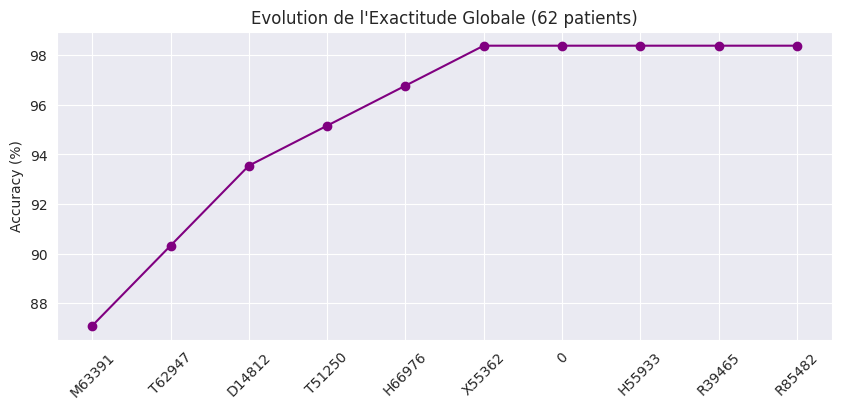

In [2]:
available_features = list(range(X_scaled_full.shape[1]))
feature_names = X_raw.columns.tolist()
selected_indices = []
selected_names = []
global_accuracies = []

print("Calcul de la sélection globale...")
for step in range(10): # On regarde les 10 premiers
    best_acc = 0.0
    best_idx = None
    
    for idx in available_features:
        temp_indices = selected_indices + [idx]
        model = LogisticRegression(random_state=42)
        model.fit(X_scaled_full[:, temp_indices], y_raw)
        acc = accuracy_score(y_raw, model.predict(X_scaled_full[:, temp_indices]))
        
        if acc > best_acc:
            best_acc = acc
            best_idx = idx
            
    selected_indices.append(best_idx)
    selected_names.append(feature_names[best_idx])
    global_accuracies.append(best_acc)
    available_features.remove(best_idx)
    print(f"Étape {step+1}: {feature_names[best_idx]} -> {best_acc*100:.2f}%")

# Affichage de la courbe globale
plt.figure(figsize=(10, 4))
plt.plot(range(1, 11), [a*100 for a in global_accuracies], marker='o', color='purple')
plt.xticks(range(1, 11), selected_names, rotation=45)
plt.title('Evolution de l\'Exactitude Globale (62 patients)')
plt.ylabel('Accuracy (%)')
plt.show()

## 2. Évaluation sur Entraînement vs Test (Top 6 Gènes)
Nous prenons les 6 meilleurs gènes identifiés ci-dessus et testons leur capacité de généralisation.

--- ÉVALUATION SUR LES 6 GÈNES CHOISIS ---
Exactitude Entraînement : 91.84%
Exactitude Test : 92.31%


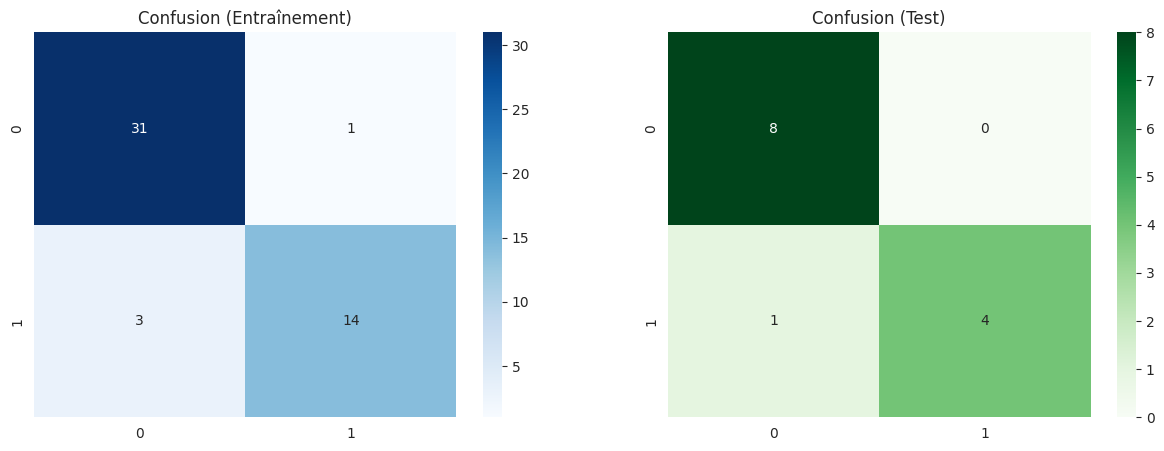

In [3]:
final_genes = selected_names[:6]
X_subset = df[final_genes]
y = y_raw

X_train, X_test, y_train, y_test = train_test_split(X_subset, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model_final = LogisticRegression(random_state=42)
model_final.fit(X_train_s, y_train)

print(f"--- ÉVALUATION SUR LES 6 GÈNES CHOISIS ---")
print(f"Exactitude Entraînement : {accuracy_score(y_train, model_final.predict(X_train_s))*100:.2f}%")
print(f"Exactitude Test : {accuracy_score(y_test, model_final.predict(X_test_s))*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(confusion_matrix(y_train, model_final.predict(X_train_s)), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion (Entraînement)')
sns.heatmap(confusion_matrix(y_test, model_final.predict(X_test_s)), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion (Test)')
plt.show()